In [641]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

## 1. Reading data

In [642]:
df_cases = pd.read_excel("../resources/weekly_varicella_hun.xlsx", sheet_name="weekly_cases")
df_age_structured_cases = pd.read_excel("../resources/age_structured_vzv_hun.xlsx", sheet_name="varicella16")
df_susceptibles = pd.read_excel("../resources/number_of_susceptibles_hun.xlsx", sheet_name="s016")
df_population = pd.read_excel("../resources/age_structured_population.xlsx", sheet_name="population16")
df_births = pd.read_excel("../resources/births_hun.xlsx", sheet_name="births")
df_deaths = pd.read_excel("../resources/age_structured_deaths_hun.xlsx", sheet_name="deaths16")
df_vaccines = pd.read_excel("../resources/vaccine_coverage_hun.xlsx", sheet_name="vaccines")
df_contacts = pd.read_excel("../resources/contact_mtx_hun.xlsx", sheet_name="contacts16", index_col=0)
df_correction = pd.read_excel("../resources/age_structured_correction.xlsx", sheet_name="correction16")

## 2. Convert dates and set indices

### 2.1 Varicella data

#### 2.1.1 Weekly cases

In [643]:
df_correction.iloc[:, 0] = (
    df_correction.iloc[:, 0]
    .astype(str)
    .str.strip()
    .str.replace("–", "-", regex=False)
)
df_correction.iloc[:, 1] = pd.to_numeric(df_correction.iloc[:, 1], errors="coerce")
correction = dict(zip(df_correction.iloc[:, 0], df_correction.iloc[:, 1]))
df_corr = df_correction.set_index(df_correction.columns[0])
correction_vector = (1 + df_corr.iloc[:, 0].values.astype(float)*10)
correction_vector = np.array([0.4,0.3,0.3,0.3,0.4,0.4,0.4,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5])

In [644]:
# "2020_1" → split year and week
df_cases[["Year", "WeekNum"]] = df_cases["Week"].str.split("_", expand=True)
df_cases["Year"] = df_cases["Year"].astype(int)
df_cases["WeekNum"] = df_cases["WeekNum"].astype(int)

# ISO week -> date (the first day of the week, Monday)
df_cases["Date"] = pd.to_datetime(df_cases["Year"].astype(str) + df_cases["WeekNum"].astype(str) + "1", format="%G%V%u")

# set date index
df_weekly_cases = df_cases.set_index("Date").sort_index()

start_of_vaccination = pd.Timestamp("2019-09-01")
start_of_age_structured_date = pd.Timestamp("2005-01-01")

detection_rate_before = 0.4
detection_rate_after = 0.4

weekly_cases = df_weekly_cases["Cases"].copy()

#weekly_cases.loc[weekly_cases.index < start_of_vaccination] *= 1 / detection_rate_before
#weekly_cases.loc[weekly_cases.index >= start_of_vaccination] *= 1 / detection_rate_after

# fill missing values
full_index = pd.date_range(
    start=start_of_age_structured_date,
    end=weekly_cases.index.max(),
    freq="W-MON"
)
weekly_cases_full = weekly_cases.reindex(full_index)
weekly_cases_filled = weekly_cases_full.interpolate(method="linear")

before_vaccination_mask = weekly_cases_filled.index < start_of_vaccination
with_vaccination_mask = weekly_cases_filled.index >= start_of_vaccination

2.1.2 Age-structured data

In [645]:
age_groups = df_age_structured_cases.iloc[:, 0].astype(str).tolist()
years = df_age_structured_cases.columns[1:].astype(int).tolist()
annual_cases = df_age_structured_cases.set_index(df_age_structured_cases.columns[0])
annual_cases.index = (
    annual_cases.index
    .map(str)          # convert all element to string
    .str.strip()       # remove whitespaces
    .str.replace("–", "-", regex=False)   # unicode dash → hyphen
)

In [646]:
def weekly_proportions_for_year(year):
    mask = weekly_cases_filled.index.year == year
    year_data = weekly_cases_filled[mask]
    total = year_data.sum()
    return year_data / total

In [647]:
weekly_age_structured = {}

for age in age_groups:
    # weekly_age_structured[age] = {}
    s = pd.Series(np.zeros(len(weekly_cases_full.index), dtype=float), index=weekly_cases_full.index)
    for year in years:
        annual_value = annual_cases.loc[age, year]
        #annual_value = annual_cases.loc[age, year] * (1/detection_rate_before)
        props = weekly_proportions_for_year(year)
        mask = weekly_cases_filled.index.year == year
        s.loc[mask] = props * annual_value
        # weekly_age_structured[age][year] = props * annual_value
    weekly_age_structured[age] = s

case_matrix = np.column_stack(
    [weekly_age_structured[age].values for age in age_groups]
).T # transpose to have shape A × T
case_matrix *= (1/correction_vector).reshape(-1, 1)

In [648]:
age_structured_data_mask = weekly_cases_filled.index.year <= max(years)
age_structured_data_index = weekly_cases_filled.loc[age_structured_data_mask].index
i = case_matrix
T = len(weekly_cases_filled[age_structured_data_mask])
A = len(age_groups)

### 2.2 Birth and death data; vaccination coverage

In [649]:
annual_deaths = df_deaths.set_index(df_deaths.columns[0])
annual_deaths.index = (
    annual_deaths.index
    .map(str)          # convert all element to string
    .str.strip()       # remove whitespaces
    .str.replace("–", "-", regex=False)   # unicode dash → hyphen
)

weekly_deaths = {}
for age in age_groups:
    s = pd.Series(np.zeros(len(weekly_cases_full.index), dtype=float), index=weekly_cases_full.index)
    for year in years:
        annual_value = annual_deaths.loc[age, year]
        mask = weekly_cases_full.index.year == year
        s.loc[mask] = annual_value / 52
    weekly_deaths[age] = s

death_matrix = np.column_stack(
    [weekly_deaths[age].values for age in age_groups]
).T # transpose to have shape A × T

In [650]:
weekly_index = weekly_cases_filled[age_structured_data_mask].index

# Yearly data in dictionary format
births_yearly = dict(zip(df_births["Year"], df_births["Cases"]))
v1_yearly = dict(zip(df_vaccines["Year"], df_vaccines["1st dose"]))
v2_yearly = dict(zip(df_vaccines["Year"], df_vaccines["2nd dose"]))

# Empty series for the weekly data
weekly_births = pd.Series(index=weekly_index, dtype=float)
weekly_v1 = pd.Series(index=weekly_index, dtype=float)
weekly_v2 = pd.Series(index=weekly_index, dtype=float)

# Filling
for date in weekly_index:
    year = date.year
    weekly_births.loc[date] = births_yearly[year] / 52
    # weekly_births.loc[date] = births_yearly[year] * birth_rates[date.weekofyear]
    birth_date_of_vaccinated = date + pd.DateOffset(months=-1)
    if date < start_of_vaccination:
        weekly_v1.loc[date] = 0
        weekly_v2.loc[date] = 0
    elif (date >= start_of_vaccination) & (date < pd.Timestamp("2020-01-01")):
        weekly_v1.loc[date] = v1_yearly[year] / (52 - start_of_vaccination.weekofyear)
        weekly_v2.loc[date] = 0
    elif date < start_of_vaccination + pd.DateOffset(months=18):
        weekly_v1.loc[date] = v1_yearly[year] / 52
        weekly_v2.loc[date] = 0
    else:
        weekly_v1.loc[date] = v1_yearly[year] / 52
        weekly_v2.loc[date] = v2_yearly[year] / 52


birth_mtx = np.zeros((A,T))
birth_mtx[0, :] = weekly_births

### 2.3 Initial values

#### 2.3.1 Number of susceptibles

In [651]:
df_susceptibles.iloc[:, 0] = (
    df_susceptibles.iloc[:, 0]
    .astype(str)
    .str.strip()
    .str.replace("–", "-", regex=False)
)
df_susceptibles.iloc[:, 1] = pd.to_numeric(df_susceptibles.iloc[:, 1], errors="coerce")
S0 = dict(zip(df_susceptibles.iloc[:, 0], df_susceptibles.iloc[:, 1]))
df_S0 = df_susceptibles.set_index(df_susceptibles.columns[0])
S0_vector = df_S0.iloc[:, 0].values.astype(float)

2.3.2 Population size

In [652]:
df_population.iloc[:,0] = (
    df_population.iloc[:, 0]
    .astype(str)
    .str.strip()
    .str.replace("–", "-", regex=False)
)
df_population.iloc[:, 1] = pd.to_numeric(df_population.iloc[:, 1], errors="coerce")
N0 = dict(zip(df_population.iloc[:, 0], df_population.iloc[:, 1]))
df_N0 = df_population.set_index(df_population.columns[0])
N0_vector = df_N0.iloc[:, 0].values.astype(float)

### 2.4 Contact matrix

In [653]:
df_contacts.index = (
    df_contacts.index.astype(str)
    .str.strip()
    .str.replace("–", "-", regex=False)
)

df_contacts.columns = (
    df_contacts.columns.astype(str)
    .str.strip()
    .str.replace("–", "-", regex=False)
)

contacts0 = df_contacts.values

## Calculating the number of susceptibles

In [654]:
V1_efficacy = 0.81
V2_efficacy = 0.92
v1 = np.zeros((A, T))
v1[1,:] = weekly_v1.values
v2 = np.zeros((A, T))
v2[2,:] = weekly_v2.values
# v1 = weekly_v1.values
# v2 = weekly_v2.values

S_scen0 = np.zeros((A, T)) ## scen0 = actual scenario;
S_scen0[:, 0] = S0_vector
N = np.zeros((A, T))
N[:, 0] = N0_vector
m = np.zeros((A, A, T))

effectively_vaccinated_scen0 = np.zeros((A, T))
demographic_changes_scen0 = np.zeros((A, T))

for t in range(1, T):
    # Update the number of susceptibles
    effectively_vaccinated_scen0[:,t] = (v1[:,t - 1] * V1_efficacy) * 1 + (v2[:,t-1] - v1[:,t-1] * V1_efficacy) * V2_efficacy   *0
    demographic_changes_scen0[:,t] = birth_mtx[:,t-1] - death_matrix[:,t-1] * (S_scen0[:,t - 1] / N[:,t - 1])

    S_scen0[:,t] = S_scen0[:,t - 1] - i[:,t - 1] - effectively_vaccinated_scen0[:,t] + demographic_changes_scen0[:,t]

    # Update the population
    if ((t <= T-1) & (weekly_cases_filled.index[t+1].month == 9) & (weekly_cases_filled.index[t+1].day <= 7)):
        print("old: ")
        print(np.sum(S_scen0[:,t]))
        # age group 10+
        S_scen0[A-1,t] = S_scen0[A-1,t] + S_scen0[A-2,t]
        N[A-1,t] = N[A-1,t-1] + N[A-2,t-1] + birth_mtx[A-1,t-1] - death_matrix[A-1,t-1]

        # age groups 1 - 9
        for a in range(A-2, 0, -1):
            S_scen0[a,t] = S_scen0[a-1,t]
            N[a,t] = N[a-1,t-1] + birth_mtx[a,t-1] - death_matrix[a,t-1]

        S_scen0[0,t] = 0 + demographic_changes_scen0[0,t]
        N[0,t] = 0 + birth_mtx[0,t-1] - death_matrix[0,t-1]
        print("new: ")
        print(np.sum(S_scen0[:,t]))
    else:
        N[:,t] = N[:,t-1] + birth_mtx[:,t-1] - death_matrix[:,t-1]

old: 
8775400.923510345
new: 
8777264.6392994
old: 
8623908.796762506
new: 
8625818.862275384
old: 
8475848.258897007
new: 
8477714.783715602
old: 
8353564.70875393
new: 
8355461.127784948
old: 
8223165.832222465
new: 
8225069.007358692
old: 
8103654.782655316
new: 
8105383.044684279
old: 
7965815.326837115
new: 
7967500.55902368
old: 
7850865.837663859
new: 
7852593.613420639
old: 
7735422.950251596
new: 
7737120.083792591
old: 
7637593.703966739
new: 
7639345.659893449
old: 
7519738.770422188
new: 
7521494.949214483
old: 
7402161.877210239
new: 
7403944.763253295
old: 
7291634.239433479
new: 
7293389.200590504
old: 
7212813.351872961
new: 
7214534.712416817
old: 
7115040.719466238
new: 
7116749.760398284
old: 
6982792.45711506
new: 
6984562.183610159
old: 
6863095.120584586
new: 
6864878.465567395
old: 
6734001.701882663
new: 
6735697.424384557
old: 
6607745.7404362885
new: 
6609379.772447708
old: 
6493443.799464893
new: 
6494928.746201692


## 4. Estimate R_t using renewal equation model

In [655]:
L = 2 # length of latent period in weeks
D = 1 # length of infectious period in weeks

sigma = 1/2   # length of latent period is 2 weeks
gamma = 1   # length of infectious period is 1 week

max_tau = 3
tau = np.arange(1, max_tau+1)
g = (sigma * gamma / (gamma - sigma)) * (np.exp(-sigma * tau) - np.exp(-gamma * tau))
g = g / g.sum()          # normalizing

remainders_t = np.zeros((A,T))
remainders_when_aging_t = np.zeros((A,T))
R_t = np.zeros(T)

Ra_t = np.zeros((A,T))
rho = np.zeros(T)

for t in range(max_tau, T):
    mu_t = (death_matrix[:,t] / N[:,t]).reshape(1, -1)  # shape: (1,A)
    year = weekly_cases_filled.index[t].year

    # infectiousness kernel considering demography
    tau = np.arange(1, max_tau + 1)  # shape: (A,1)
    kernel = g.reshape(-1, 1) * np.exp(-mu_t * tau.reshape(-1, 1))

    Ni = N[:, t-1].reshape(-1, 1) ## the size of the age groups at the previous week as a column vector
    Nj = N[:, t-1].reshape(1, -1) ## the size of the age groups at the previous week as a row vector
    cm = (contacts0 * Ni + contacts0.T * Nj) / (2 * Ni)

    # weighted sum of past incidences
    denom = np.sum(i[:,t - tau] * kernel.T, axis=1) @ cm

    if denom.all() > 0 and S_scen0[:,t].all() > 0:
        s_t = S_scen0[:,t] / N[:,t]
        s_t_1 = S_scen0[:,t-1] / N[:,t-1]
        remainders_t[:,t] = i[:,t] / (s_t * denom)
        Ra_t[:,t] = remainders_t[:,t] * s_t
        R_t[t] = (remainders_t[:,t] * s_t).sum()
        rho[t] = max(abs(np.linalg.eigvals(cm * Ra_t[:,t])))
        for a in range(1,A-1):
            if S_scen0[:,t-1].all() > 0:
                remainders_when_aging_t[a,t] = i[a,t]/ ((s_t*denom)[a-1])
        remainders_when_aging_t[A-1,t] = i[A-1,t]/ ((s_t*denom)[A-2]+(s_t*denom)[A-1])

    else:
        remainders_t[:,t] = np.nan



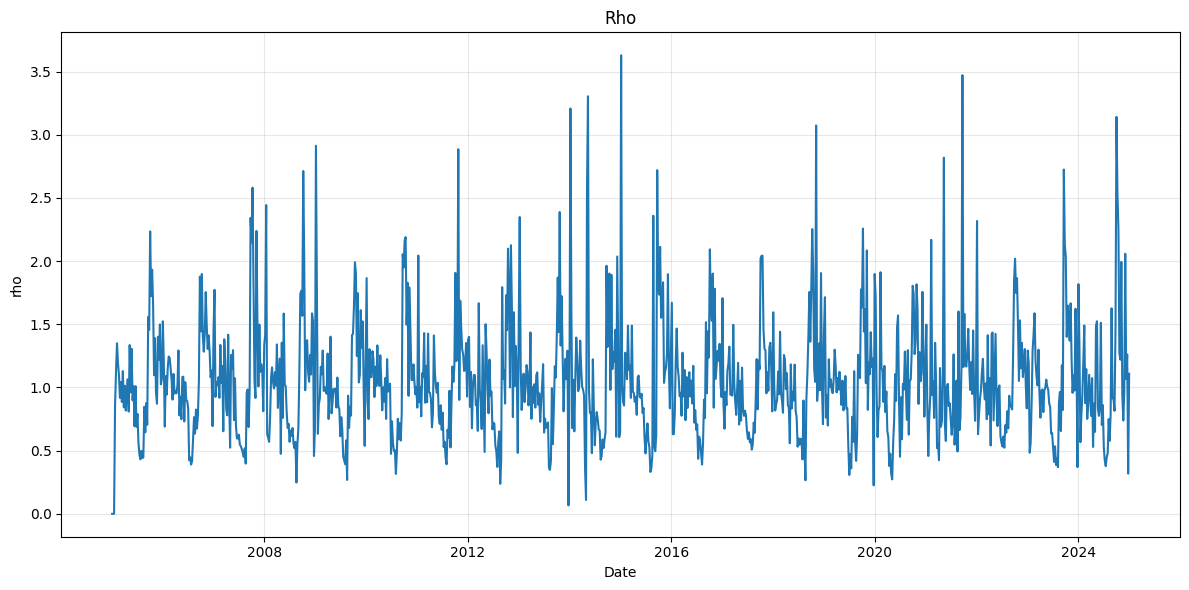

In [656]:
plt.figure(figsize=(12, 6))
plt.plot(pd.Series(rho, index=age_structured_data_index))
plt.title("Rho")
plt.xlabel("Date")
plt.ylabel("rho")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Plot results for R_t

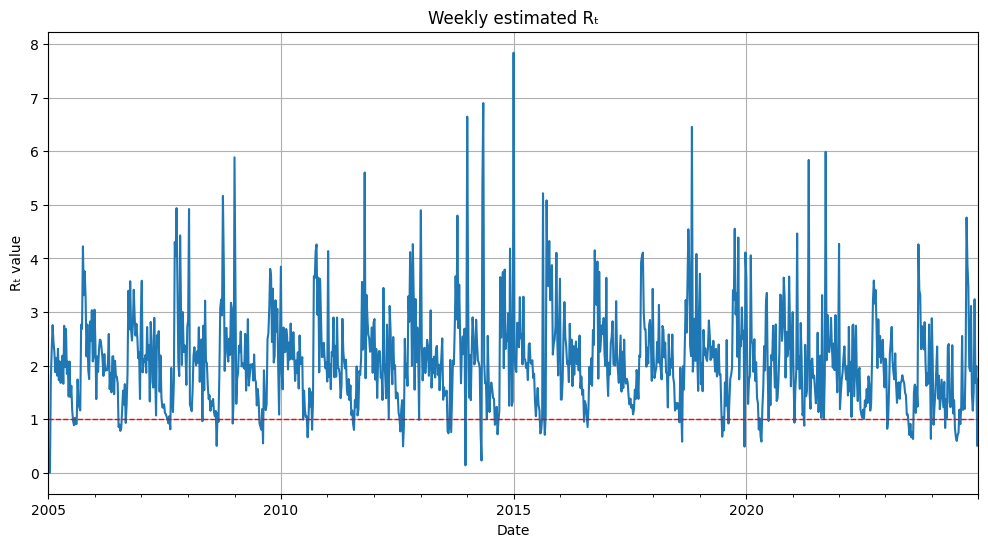

In [657]:
Ra_t = np.zeros((A,T))
rho = np.zeros(T)
for t in range(max_tau, T):
    s_t = S_scen0[:,t]/N[:,t]
    np.sum(N,axis=0)
    Ra_t[:,t] = remainders_t[:,t] * s_t
    R_t[t] = (remainders_t[:,t] * s_t).sum()

#weekly_remainders_t = pd.Series(np.sum(N,axis=0), index=age_structured_data_index)
weekly_remainders_t = pd.Series(R_t, index=age_structured_data_index)
weekly_Rt = pd.Series(R_t, index=age_structured_data_index)

plt.figure(figsize=(12, 6))
weekly_remainders_t.plot()

plt.axhline(1.0, color='red', linestyle='--', linewidth=1)  # R=1 as reference
plt.title("Weekly estimated Rₜ")
plt.ylabel("Rₜ value")
plt.xlabel("Date")
plt.grid(True)

plt.show()

## 6. Plot results for the number of incidences

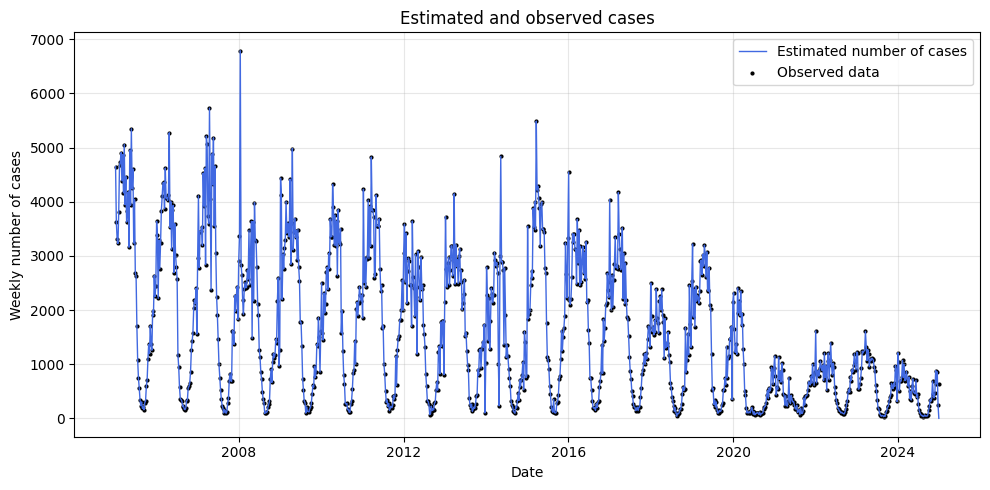

In [658]:
i_model = np.zeros((A,T))
for t in range(0, max_tau):
    i_model[:,t] = i[:,t]

for t in range(max_tau, T-1):
    s_t = S_scen0[:,t] / N[:,t]
    mu_t = (death_matrix[:,t] / N[:,t]).reshape(1, -1)  # shape: (1,A)
    tau = np.arange(1, max_tau + 1)  # shape: (A,1)
    kernel = g.reshape(-1, 1) * np.exp(-mu_t * tau.reshape(-1, 1))

    Ni = N[:, t-1].reshape(-1, 1) ## the size of the age groups at the previous week as a column vector
    Nj = N[:, t-1].reshape(1, -1) ## the size of the age groups at the previous week as a row vector
    cm = (contacts0 * Ni + contacts0.T * Nj) / (2 * Ni)
    # weighted sum of past incidences
    denom = np.sum(i[:,t - tau] * kernel.T, axis=1) @ cm

    i_model[:,t] = Ra_t[:,t] * denom

weekly_i_model = pd.Series(np.sum(i_model,axis=0), index=age_structured_data_index)

plt.figure(figsize=(10, 5))

plt.plot(weekly_i_model.index, weekly_i_model.values,
         label="Estimated number of cases", color="royalblue", linewidth=1)

plt.scatter(
    age_structured_data_index,
    #weekly_cases_filled[age_structured_data_mask].values,
    np.sum(case_matrix, axis=0)[:len(weekly_i_model)],
    color="black",
    s=4,
    label="Observed data"
)

plt.title("Estimated and observed cases")
plt.xlabel("Date")
plt.ylabel("Weekly number of cases")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

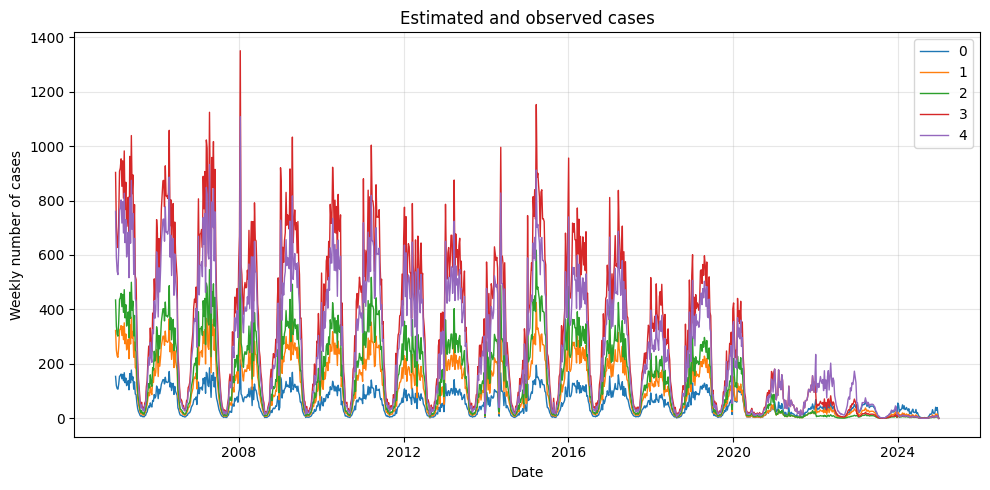

In [659]:
plt.figure(figsize=(10, 5))

for a in range(0, 5):
    plt.plot(weekly_i_model.index, pd.Series(i_model[a], index=age_structured_data_index).values,
         label=a, linewidth=1)

plt.title("Estimated and observed cases")
plt.xlabel("Date")
plt.ylabel("Weekly number of cases")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

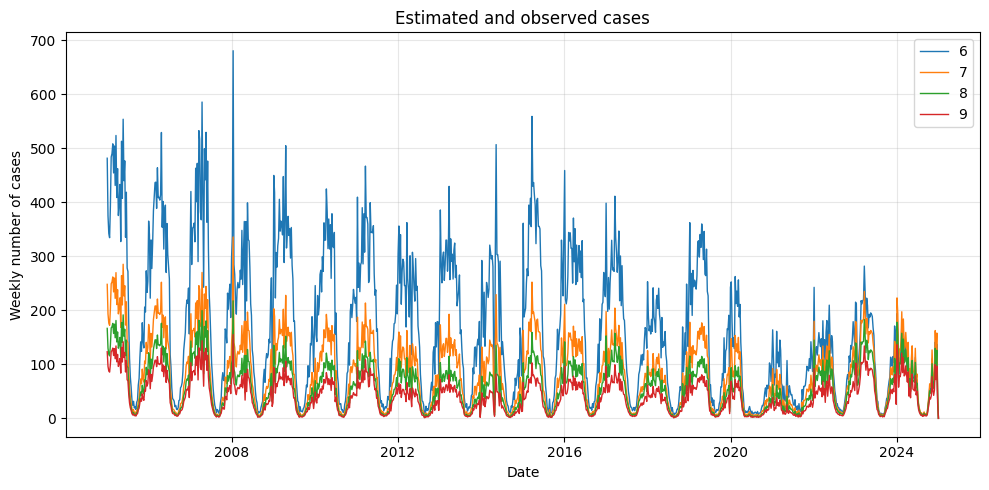

In [660]:
plt.figure(figsize=(10, 5))

for a in range(6, 10):
    plt.plot(weekly_i_model.index, pd.Series(i_model[a], index=age_structured_data_index).values,
         label=a, linewidth=1)

plt.title("Estimated and observed cases")
plt.xlabel("Date")
plt.ylabel("Weekly number of cases")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

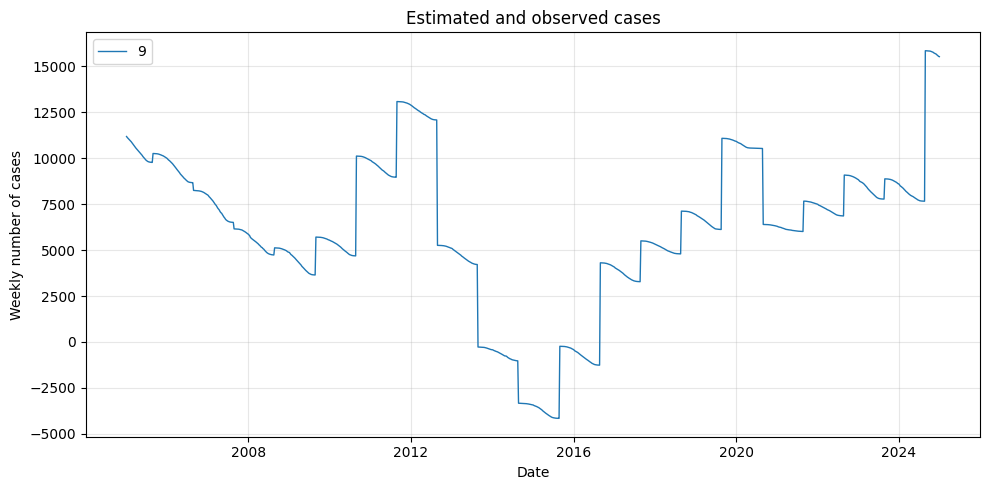

In [661]:
plt.figure(figsize=(10, 5))

plt.plot(age_structured_data_index, pd.Series(S_scen0[11], index=age_structured_data_index).values,
         label=a, linewidth=1)

plt.title("Estimated and observed cases")
plt.xlabel("Date")
plt.ylabel("Weekly number of cases")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 7. Incidences without vaccination

In [662]:
S_scen1 = np.zeros((A, T))
i_scen1 = np.zeros((A, T))
R_t_scen1 = np.zeros((A, T))
R_t_aging_scen1 = np.zeros((A, T))
effectively_vaccinated = np.zeros((A, T))
demographic_changes = np.zeros((A, T))
vaccination_level = 0

for t in range(0, max_tau):
    i_scen1[:,t] = i_model[:,t]
    S_scen1[:,t] = S_scen0[:,t]

for t in range(max_tau, T-1):
    effectively_vaccinated[:,t] = (v1[:,t - 1] * V1_efficacy) * vaccination_level
    demographic_changes[:,t] = birth_mtx[:,t-1] - death_matrix[:,t-1] * (S_scen1[:,t - 1] / N[:,t - 1])

    S_scen1[:,t] = S_scen1[:,t - 1] - i_scen1[:,t - 1] - effectively_vaccinated[:,t] + demographic_changes[:,t]
    s_t = S_scen1[:,t] / N[:,t]
    s_t_1 = S_scen1[:,t-1] / N[:,t-1]
    R_t_scen1[:,t] = remainders_t[:,t] * s_t
    R_t_aging_scen1[:,t] = remainders_when_aging_t[:,t] * s_t

    Ni = N[:, t-1].reshape(-1, 1) ## the size of the age groups at the previous week as a column vector
    Nj = N[:, t-1].reshape(1, -1) ## the size of the age groups at the previous week as a row vector
    cm = (contacts0 * Ni + contacts0.T * Nj) / (2 * Ni)
    mu_t = (death_matrix[:,t] / N[:,t]).reshape(1, -1)  # shape: (1,A)
    tau = np.arange(1, max_tau + 1)  # shape: (A,1)
    kernel = g.reshape(-1, 1) * np.exp(-mu_t * tau.reshape(-1, 1))
    denom = np.sum(i_scen1[:,t - tau] * kernel.T, axis=1) @ cm

    #i_scen1[:,t] = R_t_scen1[:,t] * denom

    # Update the population
    if ((t <= T-1) & (weekly_cases_filled.index[t+1].month == 9) & (weekly_cases_filled.index[t+1].day <= 7)):
        i_scen1[:,t] = R_t_aging_scen1[:,t] * denom
        print("old: ")
        print(np.sum(S_scen1[:,t]))
        # age group 10+
        S_scen1[A-1,t] = S_scen1[A-1,t] + S_scen1[A-2,t]
        i_scen1[A-1,t] = i_scen1[A-1,t] + i_scen1[A-2,t]

        # age groups 1 - 9
        for a in range(A-2, 0, -1):
            S_scen1[a,t] = S_scen1[a-1,t]
            i_scen1[a,t] = i_scen1[a-1,t]

        S_scen1[0,t] = 0 + demographic_changes[0,t]
        i_scen1[0,t] = i[0,t]

        print("new: ")
        print(np.sum(S_scen1[:,t]))

    else:
        i_scen1[:,t] = R_t_scen1[:,t] * denom



weekly_i_scen1 = pd.Series(np.sum(i_scen1, axis=0), index=age_structured_data_index)
weekly_s_scen1 = pd.Series(np.sum(S_scen1, axis=0), index=age_structured_data_index)

old: 
8775400.923510345
new: 
8777264.6392994
old: 
8627434.89182877
new: 
8629344.941981439
old: 
8474115.857211083
new: 
8475982.398591092
old: 
8358146.186694562
new: 
8360042.582216852
old: 
8219981.699347186
new: 
8221884.897144557
old: 
8110188.36483123
new: 
8111916.594380673
old: 
7960784.749669111
new: 
7962470.011120956
old: 
7856205.652495118
new: 
7857933.394073087
old: 
7646665.725907647
new: 
7648363.102114452
old: 
nan
new: 
nan
old: 
nan
new: 
nan
old: 
nan
new: 
nan
old: 
nan
new: 
nan
old: 
nan
new: 
nan
old: 
nan
new: 
nan
old: 
nan
new: 
nan
old: 
nan
new: 
nan
old: 
nan
new: 
nan
old: 
nan
new: 
nan
old: 
nan
new: 
nan


C:\Users\CSURITA\AppData\Local\Temp\ipykernel_23676\4268158249.py:54: RuntimeWarning: overflow encountered in multiply
  i_scen1[:,t] = R_t_scen1[:,t] * denom
C:\Users\CSURITA\AppData\Local\Temp\ipykernel_23676\4268158249.py:29: RuntimeWarning: overflow encountered in matmul
  denom = np.sum(i_scen1[:,t - tau] * kernel.T, axis=1) @ cm
C:\Users\CSURITA\AppData\Local\Temp\ipykernel_23676\4268158249.py:29: RuntimeWarning: invalid value encountered in matmul
  denom = np.sum(i_scen1[:,t - tau] * kernel.T, axis=1) @ cm
C:\Users\CSURITA\AppData\Local\Temp\ipykernel_23676\4268158249.py:17: RuntimeWarning: invalid value encountered in subtract
  S_scen1[:,t] = S_scen1[:,t - 1] - i_scen1[:,t - 1] - effectively_vaccinated[:,t] + demographic_changes[:,t]
C:\Users\CSURITA\AppData\Local\Temp\ipykernel_23676\4268158249.py:17: RuntimeWarning: invalid value encountered in add
  S_scen1[:,t] = S_scen1[:,t - 1] - i_scen1[:,t - 1] - effectively_vaccinated[:,t] + demographic_changes[:,t]
C:\Users\CSURITA\

<Figure size 1500x500 with 0 Axes>

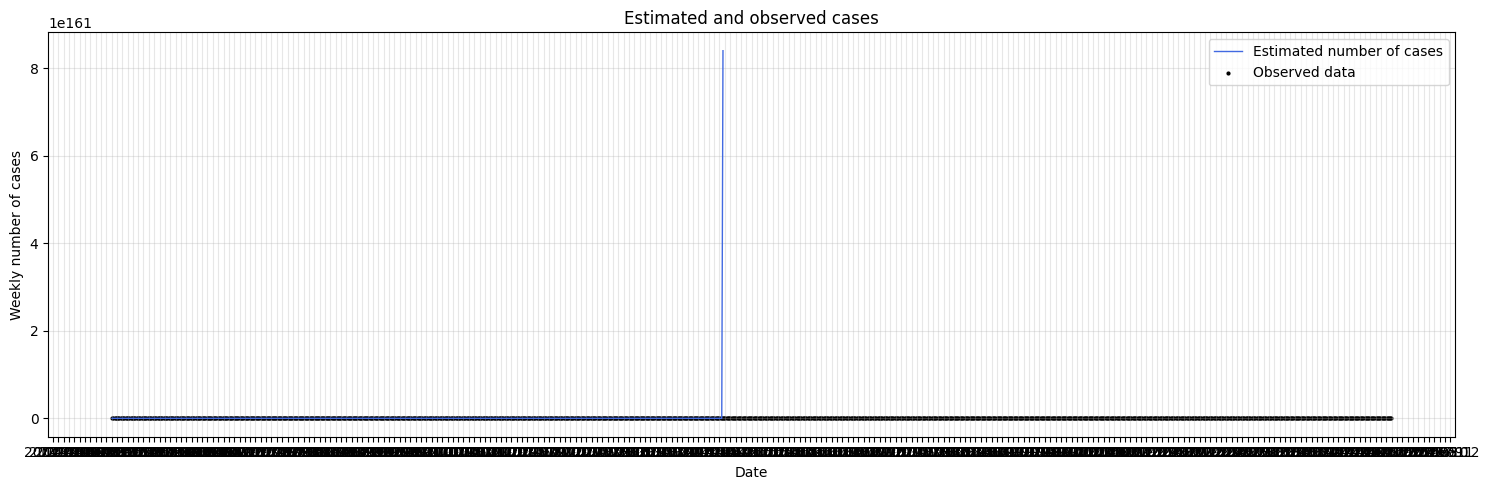

In [663]:
plt.figure(figsize=(15, 5))

fig, ax = plt.subplots()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.plot(age_structured_data_index, weekly_i_scen1.values,
         label="Estimated number of cases", color="royalblue", linewidth=1)
fig.set_size_inches(15, 5)
plt.scatter(
    age_structured_data_index,
    #np.sum(i,0)[:len(age_structured_data_index[age_structured_data_index.year < 2015])],
    np.sum(i,0)[age_structured_data_mask],
    color="black",
    s=4,
    label="Observed data"
)

plt.title("Estimated and observed cases")
plt.xlabel("Date")
plt.ylabel("Weekly number of cases")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

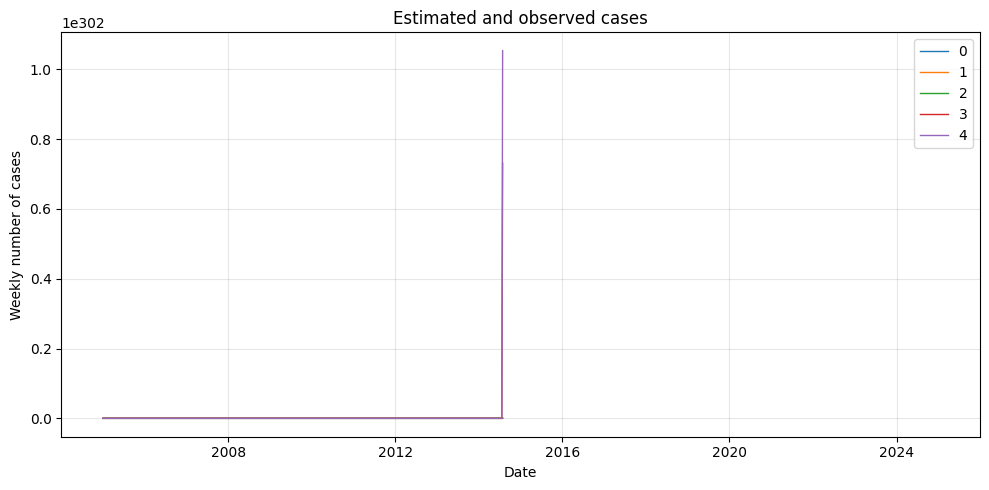

In [664]:
plt.figure(figsize=(10, 5))

for a in range(0, 5):
    plt.plot(weekly_i_model.index, pd.Series(i_scen1[a], index=age_structured_data_index).values,
         label=a, linewidth=1)

plt.title("Estimated and observed cases")
plt.xlabel("Date")
plt.ylabel("Weekly number of cases")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

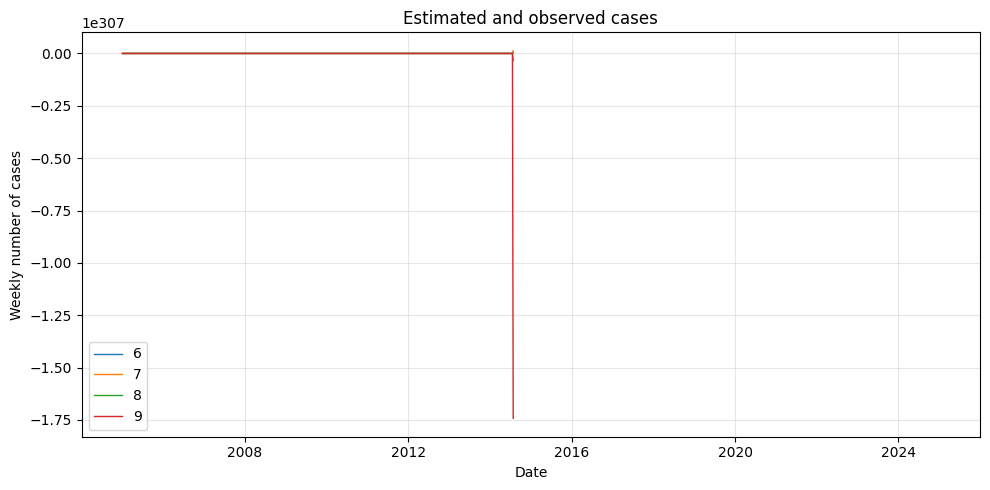

In [665]:
plt.figure(figsize=(10, 5))

for a in range(6, 10):
    plt.plot(weekly_i_model.index, pd.Series(i_scen1[a], index=age_structured_data_index).values,
         label=a, linewidth=1)

plt.title("Estimated and observed cases")
plt.xlabel("Date")
plt.ylabel("Weekly number of cases")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [666]:
annual_infections = weekly_i_scen1.groupby(weekly_i_scen1.index.year).sum()
print(annual_infections)

2005    1.353690e+05
2006    1.188788e+05
2007    1.290067e+05
2008    9.125817e+04
2009    1.122064e+05
2010    9.737192e+04
2011    1.144989e+05
2012    9.015563e+04
2013    1.790321e+05
2014             inf
2015    0.000000e+00
2016    0.000000e+00
2017    0.000000e+00
2018    0.000000e+00
2019    0.000000e+00
2020    0.000000e+00
2021    0.000000e+00
2022    0.000000e+00
2023    0.000000e+00
2024    0.000000e+00
dtype: float64
